# Data Loading

In [ ]:
# data access
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# global config
DATA_DIR = "/content/drive/MyDrive/Data Analytics Assignment/Second Assignment/09_Music_Recommendation"

Total Rows in data.csv: 170653
Total Rows in data_by_artist.csv: 28680
Total Rows in data_by_year.csv: 100
Total Rows in data_by_genres.csv: 2973


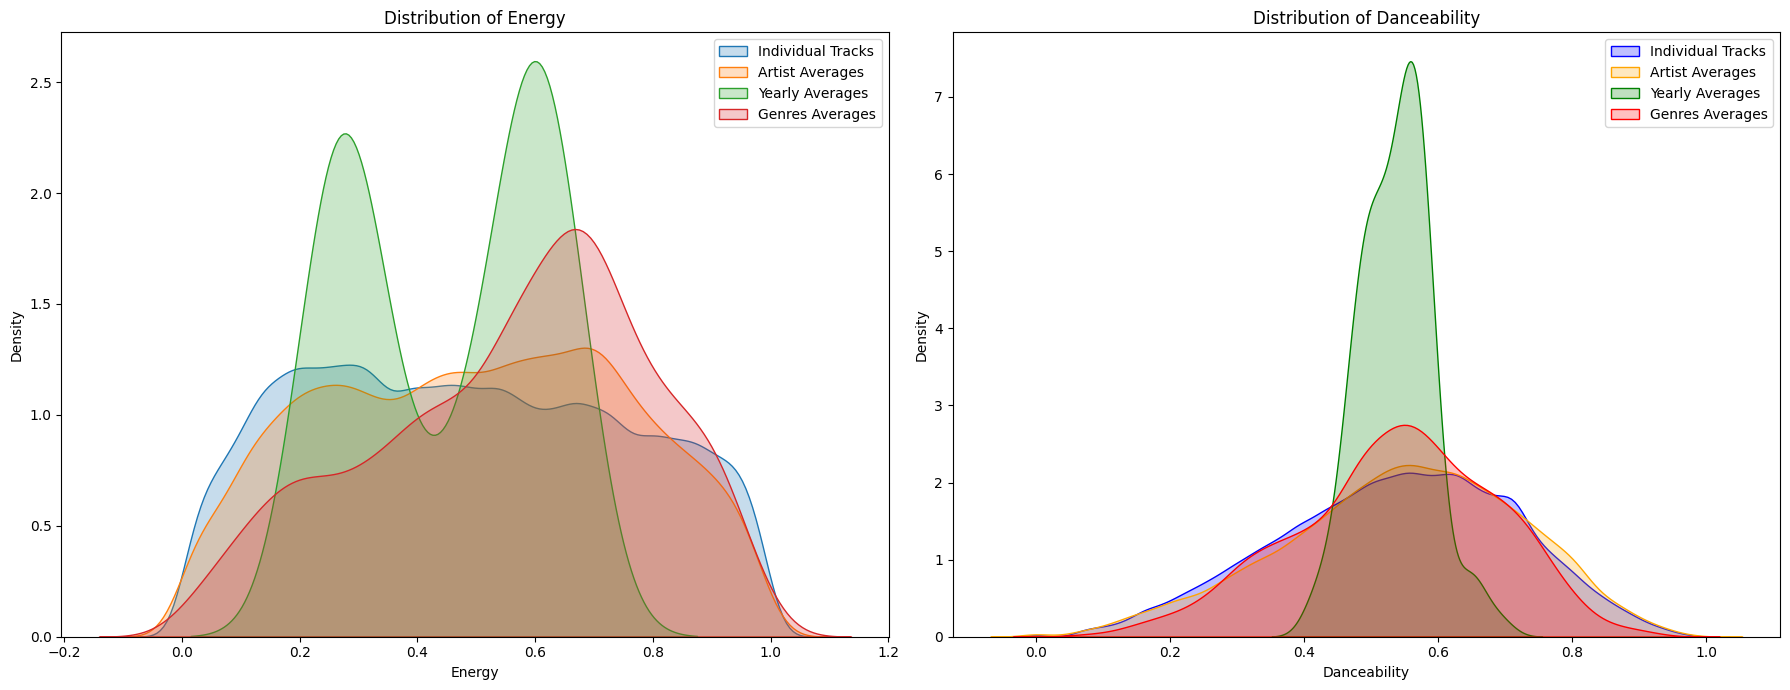

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the datasets
data = pd.read_csv(os.path.join(DATA_DIR, 'data.csv'))
data_by_artist = pd.read_csv(os.path.join(DATA_DIR, 'data_by_artist.csv'))
data_by_year = pd.read_csv(os.path.join(DATA_DIR, 'data_by_year.csv'))
data_by_genres = pd.read_csv(os.path.join(DATA_DIR, 'data_by_genres.csv'))

print(f"Total Rows in data.csv: {len(data)}")
print(f"Total Rows in data_by_artist.csv: {len(data_by_artist)}")
print(f"Total Rows in data_by_year.csv: {len(data_by_year)}")
print(f"Total Rows in data_by_genres.csv: {len(data_by_genres)}")

# 2. Side-by-Side Granularity Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Left Plot: Energy ---
sns.kdeplot(data['energy'], label='Individual Tracks', fill=True, ax=ax1)
sns.kdeplot(data_by_artist['energy'], label='Artist Averages', fill=True, ax=ax1)
sns.kdeplot(data_by_year['energy'], label='Yearly Averages', fill=True, ax=ax1)
sns.kdeplot(data_by_genres['energy'], label='Genres Averages', fill=True, ax=ax1)
ax1.set_title('Distribution of Energy')
ax1.set_xlabel('Energy')
ax1.set_ylabel('Density')
ax1.legend()

# --- Right Plot: Danceability ---
feature = 'danceability'
sns.kdeplot(data[feature], label='Individual Tracks', fill=True, color='blue', ax=ax2)
sns.kdeplot(data_by_artist[feature], label='Artist Averages', fill=True, color='orange', ax=ax2)
sns.kdeplot(data_by_year[feature], label='Yearly Averages', fill=True, color='green', ax=ax2)
sns.kdeplot(data_by_genres[feature], label='Genres Averages', fill=True, color='red', ax=ax2)
ax2.set_title(f'Distribution of {feature.capitalize()}')
ax2.set_xlabel(feature.capitalize())
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.savefig('combined_granularity.png')
plt.show()

Some tests to prove the previous point on granularity

In [ ]:
# target year
year_test = 1980

# --- Danceability Proof ---
avg_dance = data_by_year[data_by_year['year'] == year_test]['danceability'].iloc[0]
min_dance = data[data['year'] == year_test]['danceability'].min()
max_dance = data[data['year'] == year_test]['danceability'].max()

# --- Energy Proof ---
avg_energy = data_by_year[data_by_year['year'] == year_test]['energy'].iloc[0]
min_energy = data[data['year'] == year_test]['energy'].min()
max_energy = data[data['year'] == year_test]['energy'].max()

print(f"Results for {year_test}:")
print(f"Danceability: Average is {avg_dance:.2f}, but individual tracks range from {min_dance:.2f} to {max_dance:.2f}")
print(f"Energy: Average is {avg_energy:.2f}, but individual tracks range from {min_energy:.2f} to {max_energy:.2f}")

Results for 1980:
Danceability: Average is 0.56, but individual tracks range from 0.07 to 0.95
Energy: Average is 0.60, but individual tracks range from 0.00 to 1.00


Moving to the chosen main dataset:

--- Statistical Summary for Numeric Columns ---
             valence           year   acousticness   danceability   duration_ms         energy       explicit  instrumentalness            key       liveness       loudness           mode     popularity    speechiness          tempo
count  170653.000000  170653.000000  170653.000000  170653.000000  1.706530e+05  170653.000000  170653.000000     170653.000000  170653.000000  170653.000000  170653.000000  170653.000000  170653.000000  170653.000000  170653.000000
mean        0.528587    1976.787241       0.502115       0.537396  2.309483e+05       0.482389       0.084575          0.167010       5.199844       0.205839     -11.467990       0.706902      31.431794       0.098393     116.861590
std         0.263171      25.917853       0.376032       0.176138  1.261184e+05       0.267646       0.278249          0.313475       3.515094       0.174805       5.697943       0.455184      21.826615       0.162740      30.708533
min         0.000000

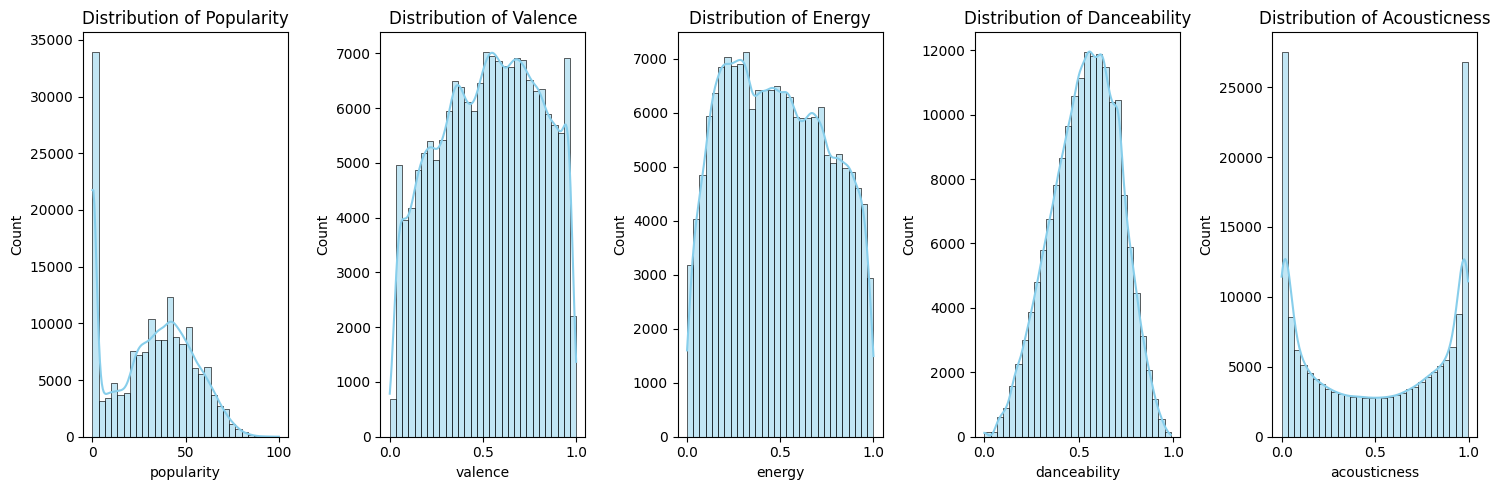

--- Outlier Detection for Mood Vibes features ---


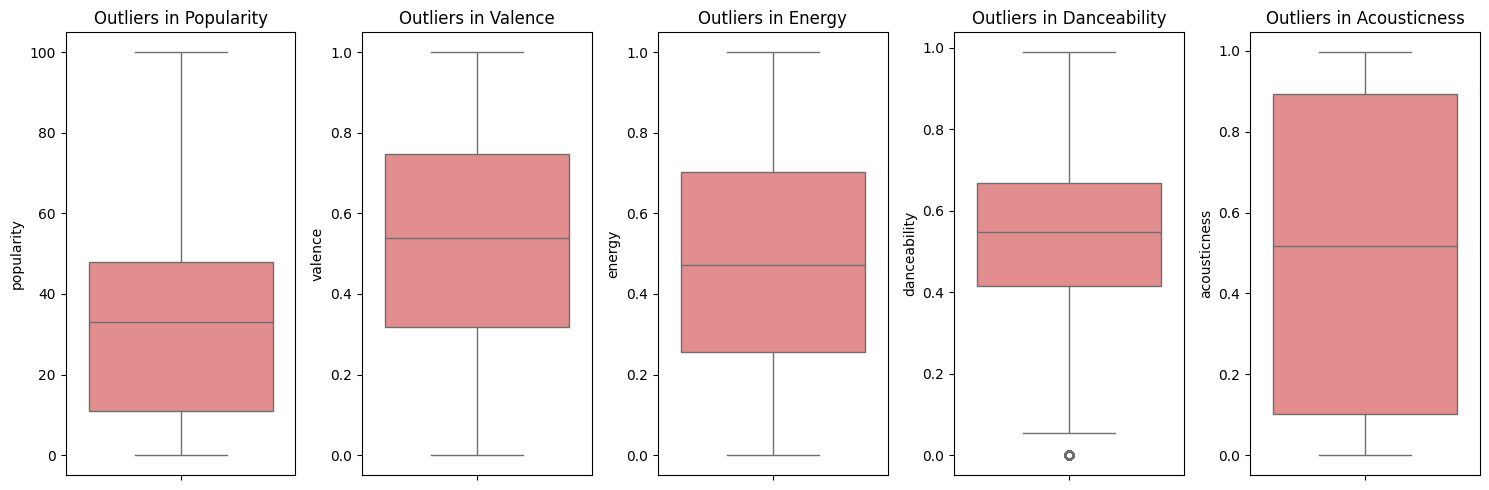

--- Distributions for Technical features ---


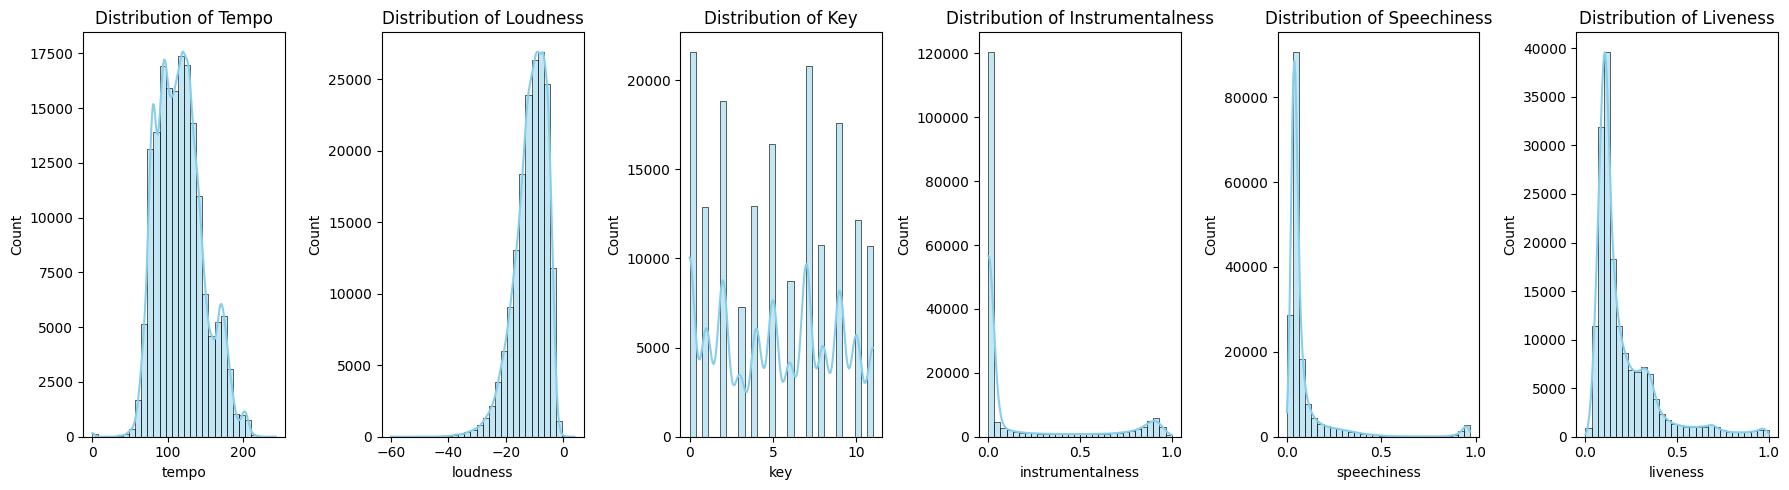

Mode analysis: 
mode
1       120635
0        50018
Name: count, dtype: int64
--- Outlier Detection for Technical features ---


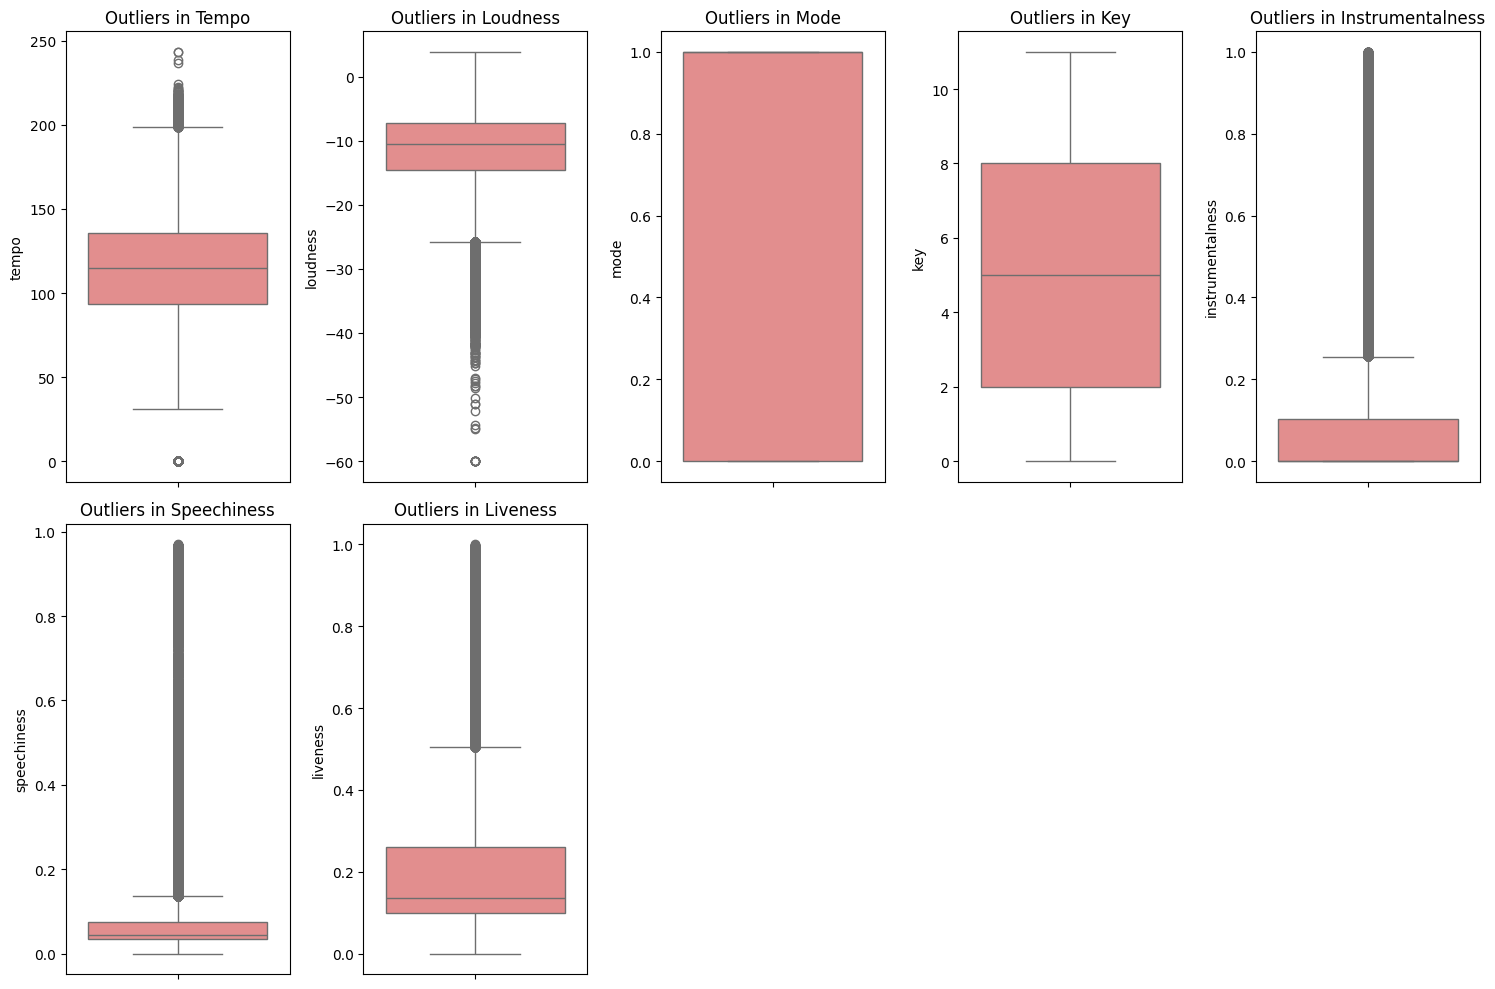


--- Categorical/Identifier Columns ---
artists          34088
name            133638
release_date     11244
dtype: int64


In [ ]:
# Load data.csv (for robustness)
df = pd.read_csv(os.path.join(DATA_DIR, 'data.csv'))

stats = df.describe()
print("--- Statistical Summary for Numeric Columns ---")
print(stats.to_string())

# Check for missing values
missing_values = df.isnull().sum()
print("\n--- Missing Values Count ---")
print(missing_values[missing_values > 0] if missing_values.any() else "No missing values found.")

# Visualizing Distributions for Mood Vibes features
print("--- Distributions for Mood Vibes features ---")
features_to_plot = ['popularity', 'valence', 'energy', 'danceability', 'acousticness']
plt.figure(figsize=(15, 5))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(1, 5, i)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {col.capitalize()}')
plt.tight_layout()
plt.savefig('feature_distributions.png')
plt.show()

# Outlier Detection for Mood Vibes features
print("--- Outlier Detection for Mood Vibes features ---")
outlier_features = ['popularity', 'valence', 'energy', 'danceability', 'acousticness']
plt.figure(figsize=(15, 5))
for i, col in enumerate(outlier_features, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Outliers in {col.capitalize()}')
plt.tight_layout()
plt.savefig('outlier_boxplots.png')
plt.show()

# Visualizing Distributions for Technical features
print("--- Distributions for Technical features ---")
features_to_plot = ['tempo', 'loudness', 'key', 'instrumentalness', 'speechiness', 'liveness']
plt.figure(figsize=(18, 5))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(1, 6, i)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {col.capitalize()}')
plt.tight_layout()
plt.savefig('feature_distributions.png')
plt.show()
# we compute also the number of 1 and 0 for the mode in the Technical features
print('Mode analysis: ')
print(df[['mode']].value_counts())

# Outlier Detection for Technical features
print("--- Outlier Detection for Technical features ---")
outlier_features = ['tempo', 'loudness', 'mode', 'key', 'instrumentalness', 'speechiness', 'liveness']
plt.figure(figsize=(15, 10))
for i, col in enumerate(outlier_features, 1):
    plt.subplot(2, 5, i)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Outliers in {col.capitalize()}')
plt.tight_layout()
plt.savefig('outlier_boxplots.png')
plt.show()

# Non-numeric description
print("\n--- Categorical/Identifier Columns ---")
print(df[['artists', 'name', 'release_date']].nunique())

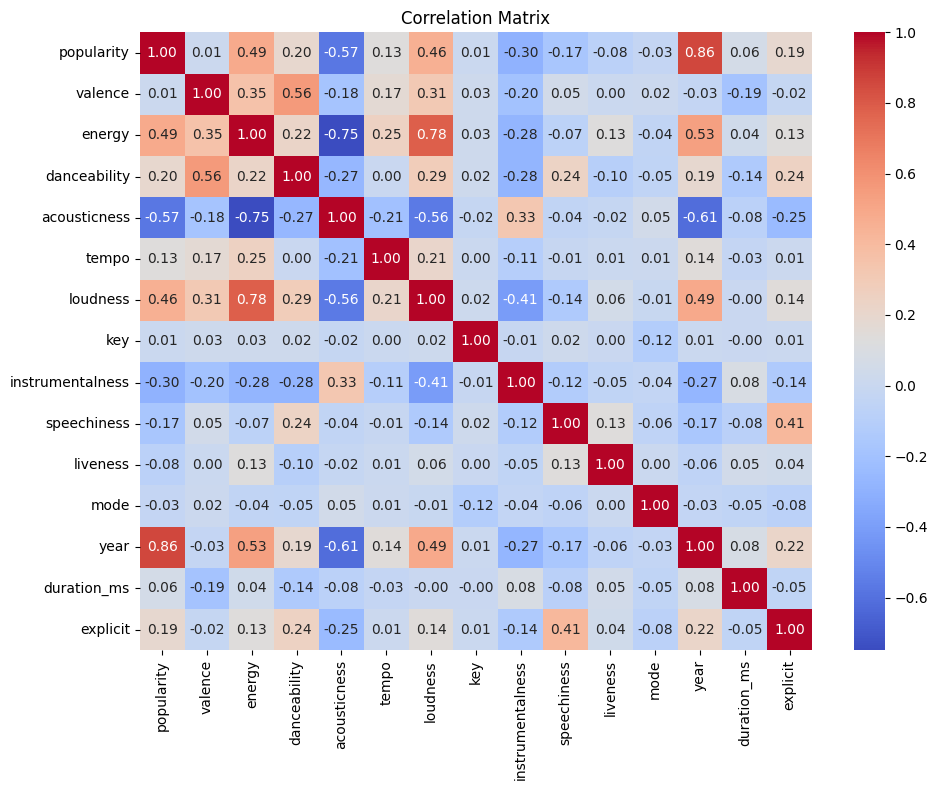

In [ ]:
# Correlation check including also some of the Track metadata
cols_to_check = ['popularity', 'valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness',
                'key', 'instrumentalness', 'speechiness', 'liveness', 'mode', 'year', 'duration_ms', 'explicit']
corr_matrix = data[cols_to_check].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

/tmp/ipykernel_13968/805965053.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='popularity', y='genres', palette='viridis', ax=axes[2])


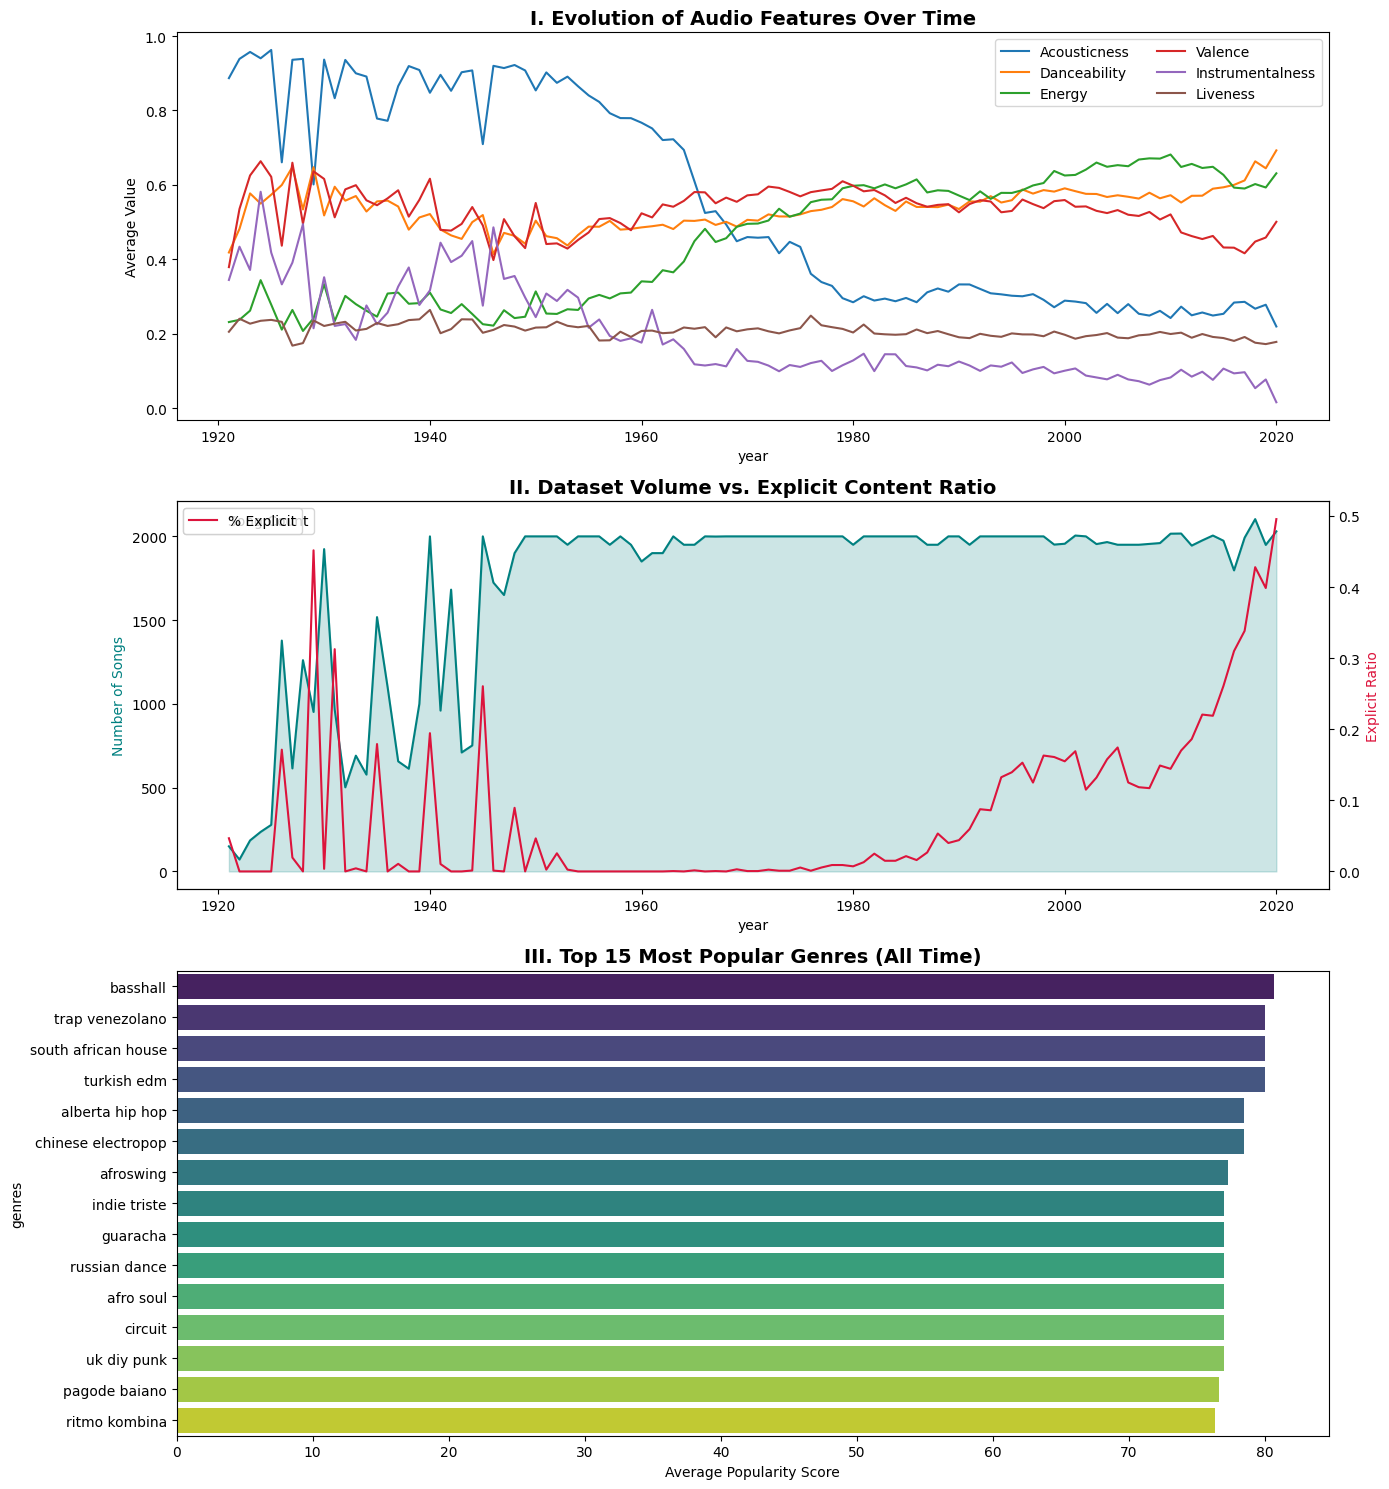


--- Decade Highlights: Most Popular Tracks ---
 year  primary_artist                        name  popularity
 1950 Ella Fitzgerald    Someone To Watch Over Me          56
 1960      Etta James                     At Last          76
 1970     The Beatles Let It Be - Remastered 2009          78
 1980           AC/DC               Back In Black          84
 1990           AC/DC               Thunderstruck          83
 2000        Coldplay                      Yellow          84
 2010           Train            Hey, Soul Sister          83
 2020       Bad Bunny                      Dakiti         100


In [ ]:
import ast

# Data Loading (for robustness)
df = pd.read_csv(os.path.join(DATA_DIR, 'data.csv'))
df_year = pd.read_csv(os.path.join(DATA_DIR, 'data_by_year.csv'))
df_genres = pd.read_csv(os.path.join(DATA_DIR, 'data_by_genres.csv'))
df_w_genres = pd.read_csv(os.path.join(DATA_DIR, 'data_w_genres.csv'))

def get_primary_artist(artist_str):
    try:
        artist_list = ast.literal_eval(artist_str)
        return artist_list[0] if isinstance(artist_list, list) and len(artist_list) > 0 else artist_str
    except:
        return artist_str

df['primary_artist'] = df['artists'].apply(get_primary_artist)

# Create the dashboard
fig, axes = plt.subplots(3, 1, figsize=(14, 15), gridspec_kw={'height_ratios': [1, 1, 1.2]})
plt.subplots_adjust(hspace=0.4)

# Plot A: Audio Feature Evolution (General Trends)
features = ['acousticness', 'danceability', 'energy', 'valence', 'instrumentalness', 'liveness']
for feature in features:
    sns.lineplot(data=df_year, x='year', y=feature, ax=axes[0], label=feature.capitalize())
axes[0].set_title("I. Evolution of Audio Features Over Time", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Average Value")
axes[0].legend(loc='upper right', ncol=2)

# Plot B: Growth vs. Explicit Content
ax2_twin = axes[1].twinx()
songs_per_year = df.groupby('year').size().reset_index(name='count')
explicit_pct = df.groupby('year')['explicit'].mean().reset_index()

sns.lineplot(data=songs_per_year, x='year', y='count', ax=axes[1], color='teal', label='Song Count')
axes[1].fill_between(songs_per_year['year'], songs_per_year['count'], alpha=0.2, color='teal')
sns.lineplot(data=explicit_pct, x='year', y='explicit', ax=ax2_twin, color='crimson', label='% Explicit')
axes[1].set_title("II. Dataset Volume vs. Explicit Content Ratio", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Number of Songs", color='teal')
ax2_twin.set_ylabel("Explicit Ratio", color='crimson')

# Plot C: Top Genres by Popularity
if 'popularity' in df_genres.columns:
    top_genres = df_genres.sort_values(by='popularity', ascending=False).head(15)
    sns.barplot(data=top_genres, x='popularity', y='genres', palette='viridis', ax=axes[2])
    axes[2].set_title("III. Top 15 Most Popular Genres (All Time)", fontsize=14, fontweight='bold')
    axes[2].set_xlabel("Average Popularity Score")

plt.tight_layout()
plt.savefig("music_evolution_dashboard.png", dpi=300)
plt.show()

# Insights Export (Text-based density)
recent_years = df[df['year'] >= 1950]
top_songs = recent_years.loc[recent_years.groupby('year')['popularity'].idxmax()][['year', 'primary_artist', 'name', 'popularity']]
print("\n--- Decade Highlights: Most Popular Tracks ---")
print(top_songs[top_songs['year'] % 10 == 0].to_string(index=False))

**Data Cleaning For Predictive Modeling**

We have no missing values, here we inspect the different scale of the variables, iteranting using boxplots:

We realised that we must apply a scaler on the numerical variables, to make them all be between 0 and 1. In addition to that, given that we are in the cleaning part, we can recall from the heatmax that Energy and Loudness are strongly correlated, so to make the model simple and reduce computing time we can drop one the two (we prefer energy given that it is already scaled between 0 and 1).

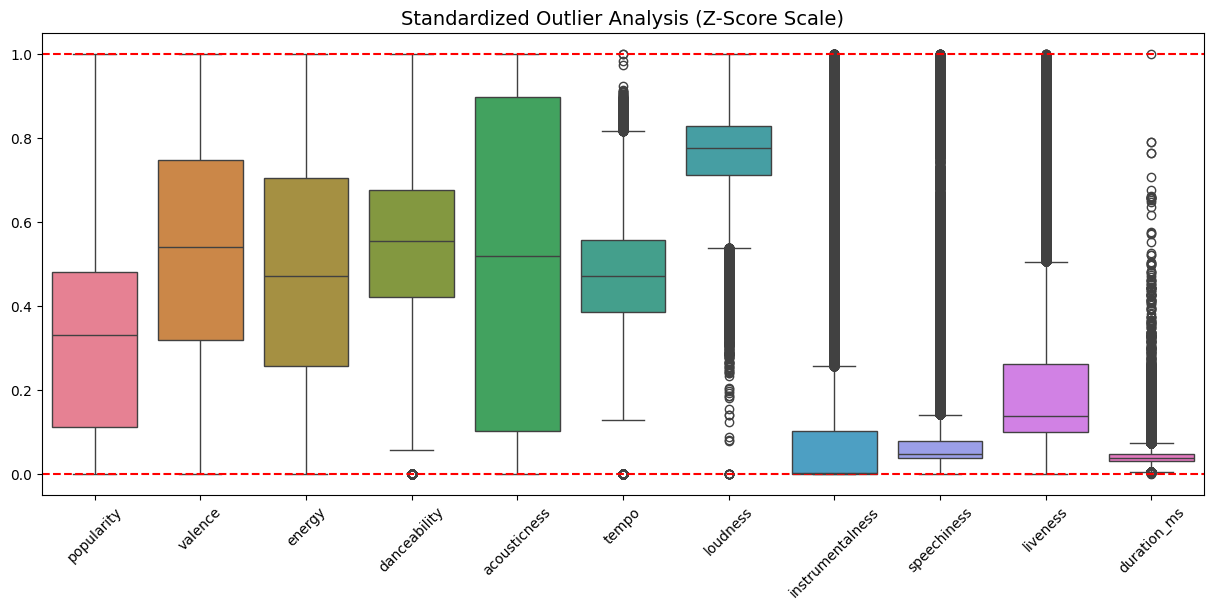

Initial shape: (170653, 20)
Final shape after cleaning: (129573, 20)
Total rows removed: 41080


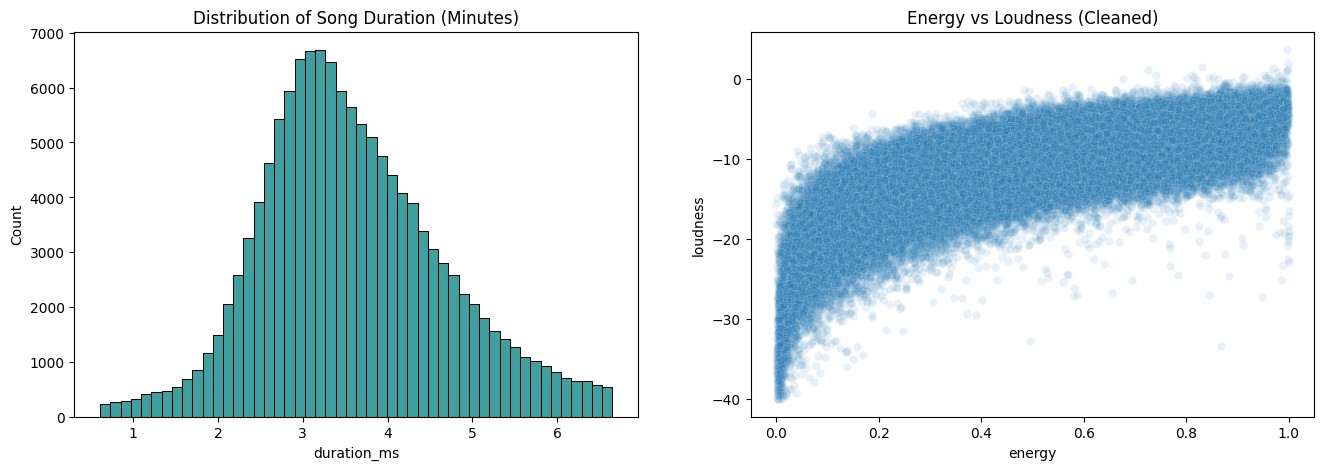

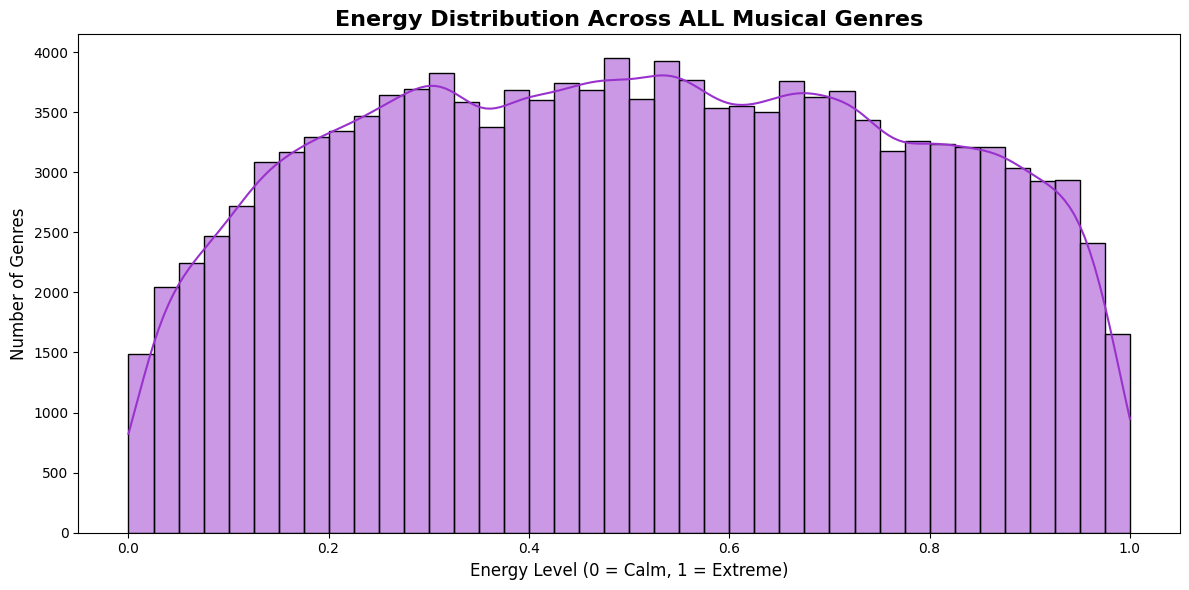

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os

# data load
df = pd.read_csv(os.path.join(DATA_DIR, 'data.csv'))
df_genres = pd.read_csv(os.path.join(DATA_DIR, 'data_w_genres.csv'))

# merging (Primary Artist Strategy)
# Instead of cleaning the whole string, we extract the first artist listed
# This increases the match rate with the genres dataset significantly
df['primary_artist'] = df['artists'].str.extract(r"'(.*?)'")[0]
df_merged = pd.merge(df, df_genres[['artists', 'genres']], left_on='primary_artist', right_on='artists', how='left')
df_merged.drop(columns=['artists_y', 'primary_artist'], inplace=True)
df_merged.rename(columns={'artists_x': 'artists'}, inplace=True)

# visualization (Standardized for Scale)
# Standardizing allows us to see ALL outliers across features with different units
audio_features = ['popularity', 'valence', 'energy', 'danceability', 'acousticness',
                  'tempo', 'loudness', 'instrumentalness', 'speechiness', 'liveness', 'duration_ms']

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_merged[audio_features]), columns=audio_features)

plt.figure(figsize=(15, 6))
sns.boxplot(data=df_scaled)
plt.title("Standardized Outlier Analysis (Z-Score Scale)", fontsize=14)
plt.xticks(rotation=45)
plt.axhline(1, color='red', linestyle='--', label='3 Std Dev')
plt.axhline(0, color='red', linestyle='--')
plt.show()

# cleaning
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

print(f"Initial shape: {df_merged.shape}")

# logical domain cleaning
df_clean = df_merged[
    (df_merged['duration_ms'].between(30000, 1200000)) &  # 30s to 20m
    (df_merged['speechiness'] < 0.66) &                  # Spotify's 'spoken word' threshold
    (df_merged['tempo'] > 40) & (df_merged['tempo'] < 220) &
    (df_merged['loudness'] > -40)
].copy()

# statistical cleaning (for features with many outliers)
# We apply IQR to duration and tempo to remove extreme tracks that skew the model
for col in ['duration_ms', 'tempo']:
    df_clean = remove_outliers_iqr(df_clean, col)

# genre cleaning (Non-musical content)
# We filter out non-music entries from the genres we just merged
noise_keywords = 'sleep|environmental|white noise|rain|nature sounds|meditation'
df_clean = df_clean[~df_clean['genres'].str.contains(noise_keywords, case=False, na=False)]
df_clean = df_clean[df_clean['genres'] != '[]']

# remove duplicates (keep the most popular version of a song)
df_clean = df_clean.sort_values('popularity', ascending=False).drop_duplicates(subset=['name', 'artists'])

# remove "Zero-Value" Corruptions
df_clean = df_clean[(df_clean['energy'] > 0) & (df_clean['danceability'] > 0)]

# final Check for Nulls (Just to be safe)
df_clean = df_clean.dropna(subset=['valence', 'energy', 'danceability', 'acousticness'])
df_clean = df_clean.reset_index(drop=True)

print(f"Final shape after cleaning: {df_clean.shape}")
print(f"Total rows removed: {len(df_merged) - len(df_clean)}")

# final inspection
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df_clean['duration_ms'] / 60000, bins=50, ax=axes[0], color='teal')
axes[0].set_title("Distribution of Song Duration (Minutes)")
sns.scatterplot(data=df_clean, x='energy', y='loudness', alpha=0.1, ax=axes[1])
axes[1].set_title("Energy vs Loudness (Cleaned)")
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(data=df_clean, x='energy', bins=40, kde=True, color='darkorchid')
plt.title("Energy Distribution Across ALL Musical Genres", fontsize=16, fontweight='bold')
plt.xlabel("Energy Level (0 = Calm, 1 = Extreme)", fontsize=12)
plt.ylabel("Number of Genres", fontsize=12)
plt.tight_layout()
plt.show()

These last plots ensure us that the data are well cleaned and not corrupted by the process.

To maintain mathematical alignment between the feature matrix and the metadata dataframe, a global index reset was performed immediately following the deduplication and outlier removal phases. This ensured that positional indexing in the Cosine Similarity calculations correctly mapped to the intended tracks.

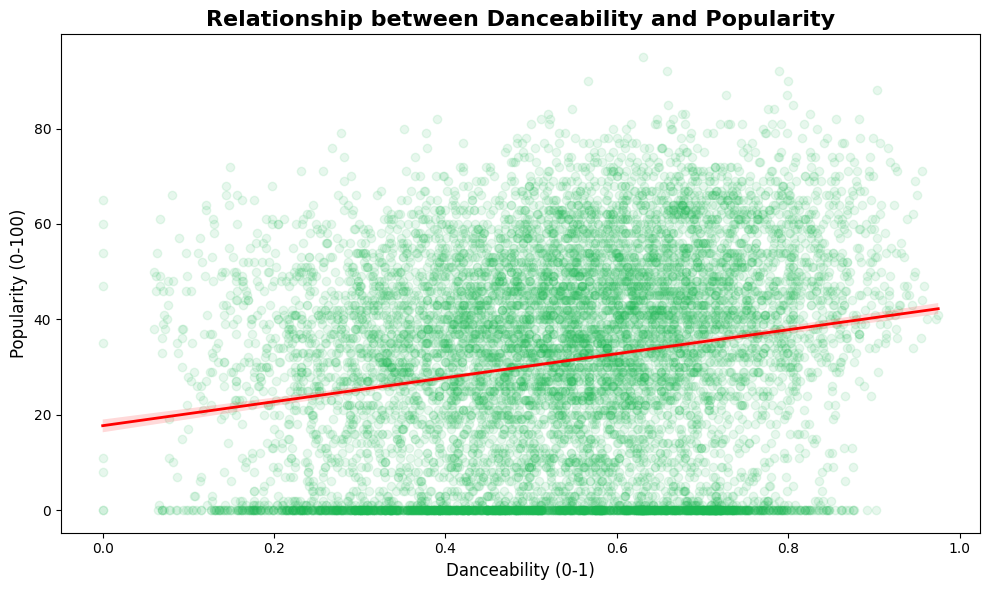

In [ ]:
# Popularity vs Danceability
plt.figure(figsize=(10, 6))

# we use a random sample of 10,000 songs to maintain plot readability and performance
df_sample = df_merged.sample(n=10000, random_state=42)

# Scatterplot with a trend line
sns.regplot(x='danceability', y='popularity', data=df_sample,
            scatter_kws={'alpha':0.1, 'color':'#1DB954'},
            line_kws={'color':'red', 'linewidth':2})

plt.title("Relationship between Danceability and Popularity", fontsize=16, fontweight='bold')
plt.xlabel("Danceability (0-1)", fontsize=12)
plt.ylabel("Popularity (0-100)", fontsize=12)
plt.tight_layout()
plt.show()

**Predictive Modeling** --> K-Means+Cosine Similarity

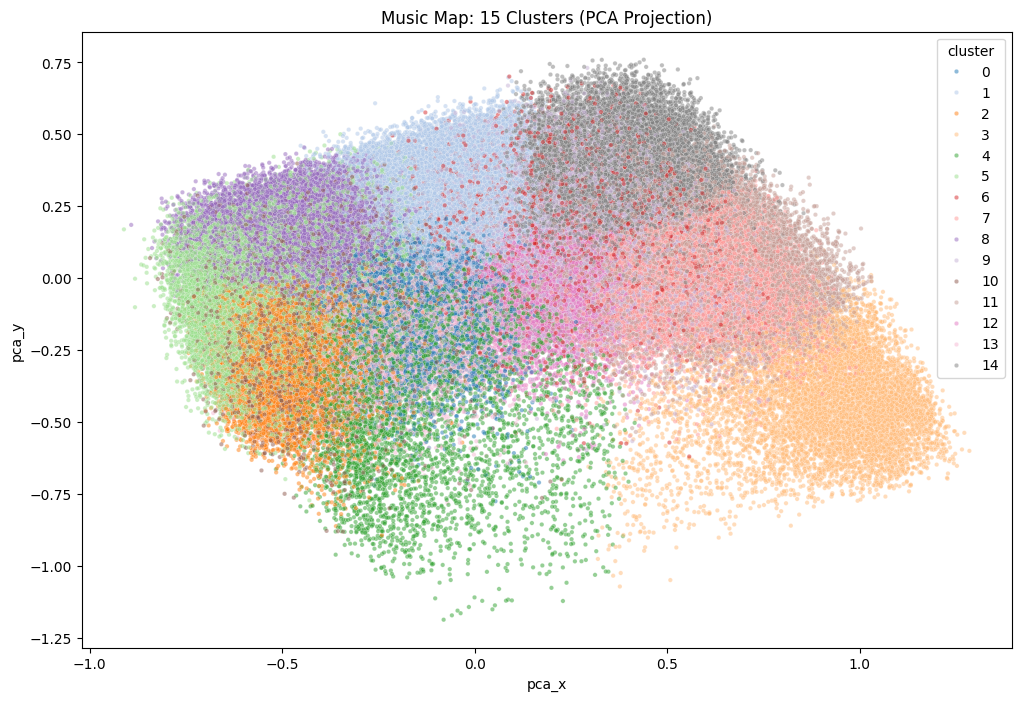

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

# Feature Selection
audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                  'liveness', 'speechiness', 'tempo', 'valence', 'popularity', 'loudness']

# scaling (Critical for distance-based models)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_clean[audio_features])

# K-Means: Grouping into 15 "Audio Families"
kmeans = KMeans(n_clusters=15, random_state=42, n_init='auto')
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

# PCA for Visualization (Reducing 8 dimensions to 2)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df_clean['pca_x'] = pca_result[:, 0]
df_clean['pca_y'] = pca_result[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(x='pca_x', y='pca_y', hue='cluster', palette='tab20', data=df_clean, s=10, alpha=0.5)
plt.title('Music Map: 15 Clusters (PCA Projection)')
plt.show()

In [ ]:
def recommend_songs(song_title, df, scaled_matrix, top_n=5):
    # Case-insensitive search
    match = df[df['name'].str.lower() == song_title.lower()]
    if match.empty:
        return None

    idx = match.index[0]
    cluster_id = df.loc[idx, 'cluster']

    # Isolate songs in the same cluster (speeds up calculation and ensures genre consistency)
    cluster_indices = df[df['cluster'] == cluster_id].index
    cluster_matrix = scaled_matrix[cluster_indices]

    # Calculate Cosine Similarity within the cluster
    target_vector = scaled_matrix[idx].reshape(1, -1)
    similarities = cosine_similarity(target_vector, cluster_matrix).flatten()

    # Map back to dataframe
    results = df.iloc[cluster_indices].copy()
    results['similarity'] = similarities

    # Filter out the input song and same artist
    input_artist = df.loc[idx, 'artists']
    recommendations = results[
        (results.index != idx) &
        (results['artists'] != input_artist)
    ].sort_values('similarity', ascending=False).head(top_n)

    return recommendations[['name', 'artists', 'year', 'similarity']]

# Test with "Bohemian Rhapsody"
test_song = "Bohemian Rhapsody - Remastered 2011"
recs = recommend_songs(test_song, df_clean, X_scaled)

print(f"Recommendations for: {test_song}")
print(recs)

Recommendations for: Bohemian Rhapsody - Remastered 2011
                                 name                      artists  year  \
7814   I'll Never Love This Way Again           ['Dionne Warwick']  1979   
12018              Perfume a Tus Pies  ['En Espíritu Y En Verdad']  2007   
709                       Tiny Dancer               ['Elton John']  1971   
4836           Have I Told You Lately             ['Van Morrison']  1989   
6797               Sleep On The Floor            ['The Lumineers']  2016   

       similarity  
7814     0.997150  
12018    0.995092  
709      0.994907  
4836     0.994700  
6797     0.994646  


In [ ]:

print("Starting Multi-Genre Recommendation Test...")
test_tracks = [
    "On The Floor",                          # Dance/Pop
    "Beat It",                               # Rock/Pop
    "Yesterday - Remastered 2009",           # Acoustic/Classic
    "Smells Like Teen Spirit",               # Grunge/Rock
    "The Thrill Is Gone",                    # Blues
    "Bohemian Rhapsody - Remastered 2011"    # Progressive Rock
]

for track in test_tracks:
    results = recommend_songs(track, df_clean, X_scaled)

    print('\n' + "-"*80 + '\n')
    print(f"Recommendations for: {track}")
    if isinstance(results, pd.DataFrame):
        display(results.reset_index(drop=True))
    else:
        print(results)
    print("\n" + "-"*80 + "\n")

Starting Multi-Genre Recommendation Test...

--------------------------------------------------------------------------------

Recommendations for: On The Floor


,name,artists,year,similarity
0,No Dices Mas,['Mœnia'],1999,0.999408
1,Up,['Justin Bieber'],2010,0.998754
2,Strangers Like Me,['Phil Collins'],1999,0.998426
3,Ass Back Home (feat. Neon Hitch),"['Gym Class Heroes', 'Neon Hitch']",2011,0.998297
4,Satellite,['Dave Matthews Band'],1994,0.998250



--------------------------------------------------------------------------------


--------------------------------------------------------------------------------

Recommendations for: Beat It


,name,artists,year,similarity
0,The One That Got Away,['Katy Perry'],2012,0.998993
1,"What Is Love - 7"" Mix",['Haddaway'],1993,0.998886
2,Our House,['Madness'],1983,0.998815
3,Hot Rod,['Dayglow'],2019,0.998791
4,Never Be Sorry,['Old Dominion'],2019,0.998687



--------------------------------------------------------------------------------


--------------------------------------------------------------------------------

Recommendations for: Yesterday - Remastered 2009


...


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------

Recommendations for: The Thrill Is Gone


,name,artists,year,similarity
0,Bambi,['Hippo Campus'],2018,0.998870
1,Here Kitty Kitty,['Twang and Round'],2011,0.998255
2,Pull Up,['Luh Kel'],2019,0.997704
3,Boyfriend,['Justin Bieber'],2012,0.997679
4,All We Know,"['The Chainsmokers', 'Phoebe Ryan']",2016,0.997551



--------------------------------------------------------------------------------


--------------------------------------------------------------------------------

Recommendations for: Bohemian Rhapsody - Remastered 2011


,name,artists,year,similarity
0,I'll Never Love This Way Again,['Dionne Warwick'],1979,0.997150
1,Perfume a Tus Pies,['En Espíritu Y En Verdad'],2007,0.995092
2,Tiny Dancer,['Elton John'],1971,0.994907
3,Have I Told You Lately,['Van Morrison'],1989,0.994700
4,Sleep On The Floor,['The Lumineers'],2016,0.994646



--------------------------------------------------------------------------------



Now we move to the second model:

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

# Define the features for the KNN model
content_features = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                    'liveness', 'speechiness', 'tempo', 'valence', 'popularity']

# Initialize and train the KNN model
# we used Euclidean distance as an alternative to cosine similarity
model_knn = NearestNeighbors(metric='euclidean', algorithm='brute', n_neighbors=10)
model_knn.fit(X_scaled)

def recommend_knn(song_title, df, scaled_matrix, model, top_n=5):
    # Search for the target song
    match = df[df['name'].str.lower() == song_title.lower()]
    if match.empty:
        return "Song not found."

    idx = match.index[0]

    # Find the nearest neighbors
    # query requires a 2D array
    distances, indices = model.kneighbors(scaled_matrix[idx].reshape(1, -1), n_neighbors=top_n+1)

    # Remove the first result (which is the input song itself)
    similar_indices = indices.flatten()[1:]
    similar_distances = distances.flatten()[1:]

    recommendations = df.iloc[similar_indices].copy()
    recommendations['distance_score'] = similar_distances

    return recommendations[['name', 'artists', 'year', 'distance_score']]

# Test the new KNN model
test_song_knn = "Beat It"
print(f"Recommendations KNN (Euclidean Distance) for: {test_song_knn} ")
display(recommend_knn(test_song_knn, df_clean, X_scaled, model_knn))

--- Raccomandazioni KNN (Distanza Euclidea) per: Beat It ---


,name,artists,year,distance_score
3037,All About That Bass,['Meghan Trainor'],2015,0.125290
620,Toxic,['Britney Spears'],2003,0.131323
5262,La Mordidita (feat. Yotuel),"['Ricky Martin', 'Yotuel']",2015,0.134535
4190,Lips Are Movin,['Meghan Trainor'],2015,0.142001
1110,(I Can't Get No) Satisfaction - Mono Version,['The Rolling Stones'],1965,0.142405
